# **SEMINAR 2**

**This time, you will implement a Support Vector Machine (SVM) algorithm that
classifies human poses. To do that, you will not use images but instead, Wi-Fi signals. Wi-Fi sensing has recently attracted a lot of attention thanks to the plethora of
use cases that can be covered, including positioning, object detection, seeing through
walls, measuring vital signs, etc. The dataset that you are going to use in this seminar (dataset Seminar2.zip) contains Wi-Fi signals (in the form of Channel State
Information matrix) measured when a person was doing a given pose (e.g., walk, run,
sit down, etc.).1 The goals of this seminar are as follows: (1) understand the Wi-Fi
signals (CSI) to be used as features, (2) train and evaluate a classifier based on SVM
using the target dataset.**

**PART** **1**

**The provided dataset contains features (CSI matrices) and labels (human poses), which are
split into train and test partitions. Apart from that, SkelletonPoints are provided to
visualize the actual pose captured with a camera. In this first part, you will have to prepare
and understand the data that you are going to use to train and evaluate your SVM. Complete
the following tasks:**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import classification_report, accuracy_score
from sklearn import svm

1.1. **Create a function/script that takes SkelletonPoints as input and plots the corresponding pose. Your plotting function should also display the label associated with the pose being plotted.**

In [2]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


The data consists of three main components: skeleton points (spatial coordinates for pose visualitzation), labels (numerical categories representing the 5 human poses) and features (the CSI matrices derived from Wi-Fi signals).

In [3]:
path = '/content/drive/Shared drives//ML4N/seminar 2/'
data = pd.read_csv(path + 'Train_skelletonpoints.csv', delimiter=',', header=None)
labels = pd.read_csv(path + 'Train_labels.csv', delimiter=',', header=None)
features = pd.read_csv(path + 'Train_features.csv', delimiter=',', header=None)

We defined a function to map numerical labels to their corresponding human activities: wave, push, crouch, sitdown and bend.

In [4]:
def pose(num) -> str:
  if num == 1:
    pos = 'wave'
  elif num == 2:
    pos = 'push'
  elif num == 3:
    pos = 'crouch'
  elif num == 4:
    pos = 'sitdown'
  elif num == 5:
    pos = 'bend'

  return pos


Here we separate the 36 skeleton columns into x and y spatial coordinates. Also, we plot the 18 key points of the human body.

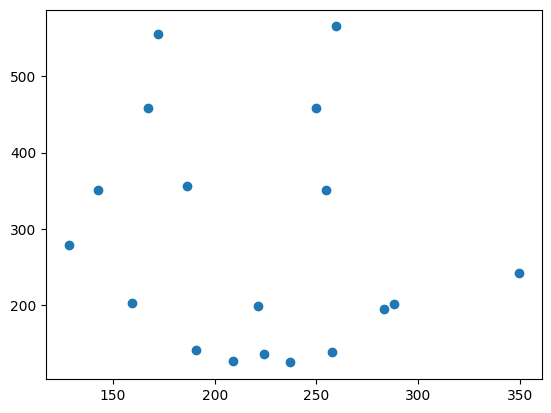

In [5]:
x_points = [data[i] for i in range(0,18)]
y_points = [data[i]for i in range(18,36)]

i = 0

x_mostra = [serie.iloc[i] for serie in x_points ]
y_mostra = [serie.iloc[i] for serie in y_points ]

plt.scatter(y_mostra, x_mostra)
plt.show()



The list of the connections in the slides was used here, after a scatter plot was used for the joints and finally we inverted the Y-axis to correctly align the vertical orientation of the skeleton.

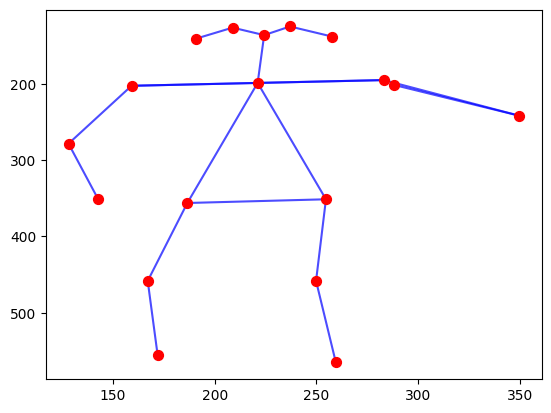

wave


In [6]:
# Definir las conexiones entre los 18 puntos clave (basado en MPII)
connections_18 = [
    [1, 2],   # Nose - Neck
    [2, 3],   # Neck - Right Shoulder
    [3, 4],   # Right Shoulder - Right Elbow
    [4, 5],   # Right Elbow - Right Wrist
    [2, 6],   # Neck - Left Shoulder
    [6, 7],   # Left Shoulder - Left Elbow
    [7, 8],   # Left Elbow - Left Wrist
    [2, 9],   # Neck - Right Hip
    [9, 10],  # Right Hip - Right Knee
    [10, 11], # Right Knee - Right Ankle
    [2, 12],  # Neck - Left Hip
    [12, 13], # Left Hip - Left Knee
    [13, 14], # Left Knee - Left Ankle
    [1, 15],  # Nose - Right Eye
    [1, 16],  # Nose - Left Eye
    [15, 17], # Right Eye - Right Ear
    [16, 18], # Left Eye - Left Ear
    [3, 6],   # Right Shoulder - Left Shoulder
    [9, 12]   # Right Hip - Left Hip
]

plt.scatter(y_mostra, x_mostra, color='red', s=50, zorder=3)

for start, end in connections_18:
    plt.plot([y_mostra[start-1], y_mostra[end-1]], [x_mostra[start-1], x_mostra[end-1]], 'b-', alpha=0.7)

plt.gca().invert_yaxis()

plt.show()

print(pose(labels[i].iloc[0]))

1.2. **Now, focus on the CSI data (for instance, from Train features.csv) and implement
the code for plotting the average CSI amplitude per subcarrier. Such a plot should
allow for understanding the status of the channel at a given specific moment and for a
specific subcarrier.**

The objective of this section is to transform the raw features into a structured format to analyze the Channel State Information (CSI).

In [7]:
features

,0,1,2,3,4,5,6,7,8,9,...,260,261,262,263,264,265,266,267,268,269
0,5.1190,6.6859,5.6623,8.9701,10.32800,10.4760,10.6660,9.9323,8.1979,14.0570,...,12.6730,12.0120,9.4553,11.9600,8.7790,8.4022,9.1572,9.6968,9.8857,2.2209
1,6.3390,8.4133,8.9647,9.4351,7.90180,9.4351,11.0360,14.2070,16.5860,16.2090,...,10.6800,7.7437,9.5166,7.8034,7.2276,4.0475,3.1450,2.2923,2.8349,2.2923
2,12.4700,17.3240,19.5110,20.8220,18.47900,16.2400,18.7050,20.5740,22.8850,22.2860,...,13.5690,12.0390,13.3030,9.9292,7.7475,6.0064,5.1415,5.1415,4.2472,2.2994
3,4.7570,9.0634,9.8658,9.2160,7.97160,7.3230,7.2593,6.6811,11.2600,9.0634,...,3.9369,9.3330,12.3240,8.2768,8.5168,10.6370,8.3514,8.6969,6.7043,11.1910
4,2.0073,1.5746,1.5746,1.2449,2.78360,2.8387,3.5210,2.8387,2.2954,2.8387,...,2.2954,3.8970,3.3864,4.0530,3.5210,4.0530,3.9366,2.9980,2.4897,1.7605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2.2148,2.9817,3.3222,2.7685,0.78304,1.2381,5.9891,6.3131,5.9635,5.4532,...,5.1048,5.5646,5.5646,6.6674,6.7360,7.7121,4.7631,4.4640,2.9817,3.3680
996,3.2132,6.6356,10.1610,14.2210,15.76100,14.9900,24.0260,27.6900,33.8080,31.8900,...,35.6100,37.9590,36.3860,35.0780,31.3280,31.4150,27.8490,25.6640,26.5420,19.2240
997,6.2116,8.3337,9.1965,9.8918,11.25000,8.7845,9.7187,8.2593,5.5000,4.9692,...,3.5138,6.0095,4.9692,5.6658,5.0310,5.6658,5.4718,4.3392,4.0063,2.9919
998,17.8880,23.1970,25.6060,28.4650,29.77400,26.4830,27.1330,26.7200,26.7200,23.8920,...,20.6200,21.1150,23.3170,24.1170,21.2610,21.1520,20.1280,17.7840,14.4100,9.4919


To make the data interpretable, we reshape the features into a 4 dimension tensor: samples, subcarriers, transmit antennas and receive antennas.

To understand the overall status of the wireless channel, we calculate the average amplitude per subcarrier. For this, we compute the mean across all samples and antenna pairs.

The resulting plot illustrates the frequency response of the channel, helping identify which subcarriers are more affected by fading or interference during the data collection process.

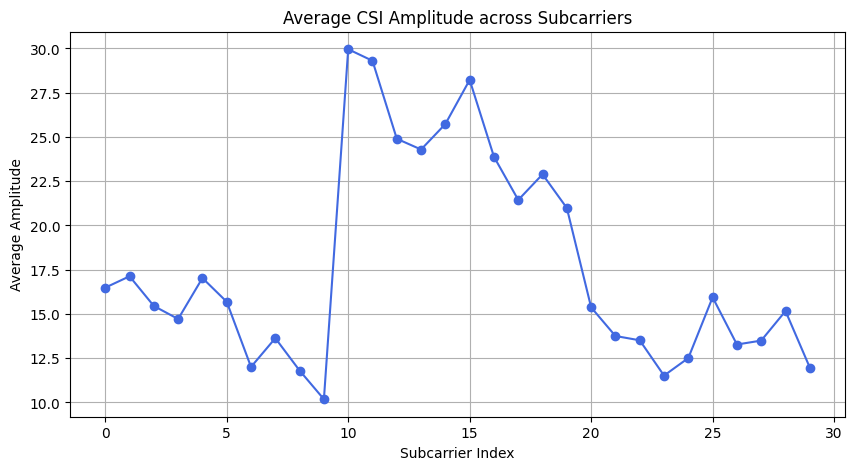

In [20]:
data = features

n_samples = features.shape[0]
n_subcarriers = 30
n_tx = 3
n_rx = 3

csi = data.reshape(n_samples, n_subcarriers, n_tx, n_rx)
avg_amplitude = np.mean(csi, axis=(0,2,3))

plt.figure(figsize=(10, 5))
plt.plot(range(n_subcarriers), avg_amplitude, marker='o', color='royalblue')
plt.title('Average CSI Amplitude across Subcarriers')
plt.xlabel('Subcarrier Index')
plt.ylabel('Average Amplitude')
plt.grid(True)
plt.show()


1.3. **Finally, plot the distribution of the CSI amplitude across each subcarrier for each class.**

In this task, we perform a statistical analysis of the CSI amplitude to visualize the effect that each movement causes on the Wi-Fi signal. To achieve this, we first flatten the labels into a 1D array and reshape the features to calculate the average amplitude across the antenna dimensions, effectively reducing complexity while preserving the essential frequency-domain characteristics of the 30 subcarriers.
Finally, we generate a vertical stack of boxplots for each class to compare their central tendencies and data spread. By utilizing subplots with shared X-axis and omitting signal attenuation or fluctuations across the frequency spectrum, which provides critical insights into the feature discriminability for our feature SVM model.

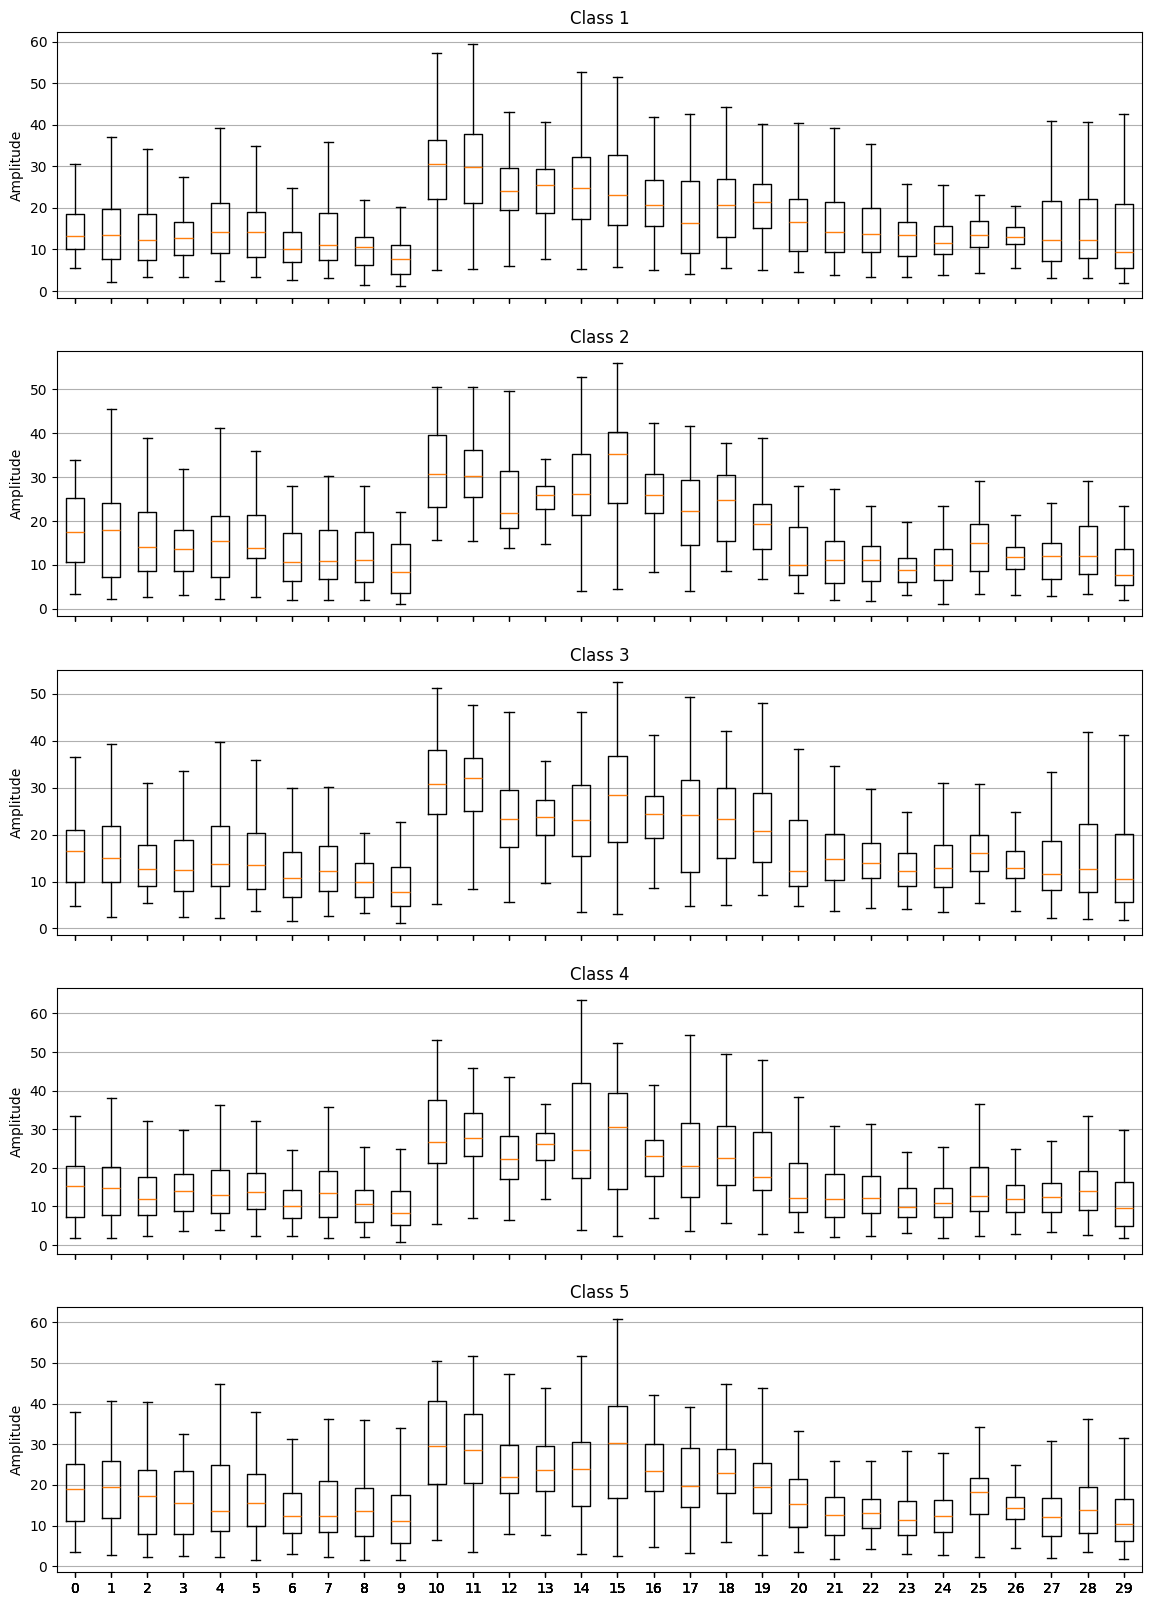

In [9]:
features = pd.read_csv(path + 'Train_features.csv', header=None).values
labels   = pd.read_csv(path + 'Train_labels.csv',   header=None).values.flatten()

classes = np.unique(labels)
n_subcarriers = 30
csi = features.reshape(len(features), n_subcarriers, -1)
amplitude = csi.mean(axis=2)

fig, axes = plt.subplots(len(classes), 1, figsize=(14, 4 * len(classes)), sharex=True)


for ax, cls in zip(axes, classes):
    mask = labels == cls
    class_data = amplitude[mask]
    ax.boxplot(class_data, positions=range(n_subcarriers), showfliers=False)
    ax.set_title(f'Class {cls}')
    ax.set_ylabel('Amplitude')
    ax.grid(True, axis='y')

plt.show()

**PART** **2**

**Once the data to be used are clear, now is the time to implement the classifier based on SVM,
so that we can guess the pose of someone simply by analyzing Wi-Fi signals. In particular,
you have to:**

2.1. **Create a module that loads the training data and fits it into an SVM. You can leverage
existing libraries that implement SVMs (e.g., pytorch)**.



• For evaluating the SVM, you should define one or more success rate metrics.

In this section, we implement a robust training module to classify human poses based on the previously analyzed Wi-Fi signals. The process begins with data normalization using the StandardScaler, which is a critical step for SVM algorithms as they are sensitive to the scale of input features; ensuring a mean of zero and unit variance allows for faster convergence and better performance. We then partition the dataset into training and testing sets using a 20% split, applying a stratified sampling strategy to maintain the original class distribution across both subsets. Finally, we initialize and fit a Support Vector Classifier (SVC) which enables the model to handle non-linear relationships between the CSI amplitudes and the corresponding physical poses by mapping the features into a higher-dimensional space.

In [10]:
def train_csi_classifier(features, labels):

  #normalize
  scaler = StandardScaler()
  X_scaled = scaler.fit_transform(features)

  #split into train and test
  X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, labels, test_size=0.2, random_state=42, stratify=labels
  )

  #fit
  clf = svm.SVC(kernel='rbf', C=1.0, gamma='scale')
  clf.fit(X_train, y_train)

  return clf, scaler


2.2. **Generate predictions on the test dataset using the SVM trained in the previous step.**

Here we utilize the trained SVM model to generate predictions on the independent test dataset. Once normalized, the features are fed into the SVM classifier to determine the predicted human pose for each CSI measurement in the test set.

In [11]:
def predictions(model, scaler, data_test):
  #normalize
  X_test_scaled = scaler.transform(data_test)

  #predict
  y_pred = model.predict(X_test_scaled)

  return y_pred


We evaluate the model by comparing its predictions against the ground truth using a validation module. We calculate the overall Accuracy for a general performance overview and generate a Classification Report featuring Precision, Recall, and F1-Score. This multi-metric approach allows us to analyze the model's effectiveness for each specific pose and identify potential confusion between similar movements, ensuring a balanced and reliable classification.

In [12]:
def validate(y_real, y_pred):
  acc = accuracy_score(y_real, y_pred)
  print(f"Accuracy: {acc}")
  print(classification_report(y_real, y_pred))

In [13]:
train_features = pd.read_csv(path + 'Train_features.csv', header=None).values
train_labels = pd.read_csv(path + 'Train_labels.csv', header=None).values.flatten()
test_features = pd.read_csv(path + 'Test_features.csv', header=None).values
test_labels = pd.read_csv(path + 'Test_labels.csv', header=None).values.flatten()

In [14]:
weights, scaler = train_csi_classifier(train_features, train_labels)
y_pred = predictions(weights, scaler, test_features)
validate(test_labels, y_pred)

Accuracy: 0.705
              precision    recall  f1-score   support

           1       0.76      0.74      0.75        42
           2       0.68      0.87      0.76        39
           3       0.74      0.80      0.77        35
           4       0.70      0.50      0.58        38
           5       0.66      0.63      0.64        46

    accuracy                           0.70       200
   macro avg       0.71      0.71      0.70       200
weighted avg       0.71      0.70      0.70       200

